In [ ]:
import paddlenlp
from datasets import load_dataset

# 加载训练集、验证集、测试集
train_path = "./data/data178684/train_ext.json"
dev_path = "./data/data178684/dev_ext.json"
test_path = "./data/data178684/test_ext.json"
dataset = load_dataset("json", data_files={"train":train_path, "dev":dev_path, "test":test_path})

# 打印训练集的前3条数据
print(dataset["train"][:3])

/home/ricaedo/下载/yes/envs/paddle/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ricaedo/下载/yes/envs/paddle/lib/python3.10/site-packages/_distutils_hack/__init__.py:30: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(
/home/ricaedo/下载/yes/envs/paddle/lib/python3.10/site-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


{'text': ['兑 换 很 方 便 ，', '跑 到 水 里 摸 螺 丝 ， 总 体 感 觉 很 不 错 ， 空 气 也 比 较 清 新 ， 是 个 周 末 度 假 的 好 地 方', '骑 车 不 错 的 地 方'], 'label': ['B-Aspect I-Aspect O B-Opinion I-Opinion O', 'O O O O O O O O B-Aspect I-Aspect I-Aspect I-Aspect O B-Opinion I-Opinion O B-Aspect I-Aspect O O O B-Opinion I-Opinion O O O O O O O O B-Opinion B-Aspect I-Aspect', 'O O B-Opinion I-Opinion O B-Aspect I-Aspect']}


In [2]:
from functools import partial
from paddlenlp.transformers import AutoTokenizer
def convert_example_to_feature(example, tokenizer, label2id, max_seq_len=512, is_infer=False):
    text = example["text"].split()
    label = example["label"].split()
    assert len(text) == len(label), "The length of text is not equal to label's: {} != {}".format(len(text), len(label))
    encoded_inputs = tokenizer(text, is_split_into_words=True, max_seq_len=max_seq_len, return_length=True)
    if not is_infer: 
        encoded_inputs["label"] =  [label2id["O"]] + [label2id[item] for item in label[:max_seq_len - 2]] + [label2id["O"]]

    return encoded_inputs

max_seq_len = 512
# 定义模型名称
model_name = "bert-base-chinese"
# 定义Bert Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)
# 定义词典
ext_label2id = {"O":0, "B-Aspect":1, "I-Aspect":2, "B-Opinion":3, "I-Opinion":4}
ext_id2label = {v: k for k, v in ext_label2id.items()}


trans_fn = partial(convert_example_to_feature, tokenizer=tokenizer, label2id=ext_label2id, max_seq_len=max_seq_len)
columns = ["text", "label"]
train_dataset = dataset["train"].map(trans_fn, batched=False, remove_columns=columns)
dev_dataset = dataset["dev"].map(trans_fn, batched=False, remove_columns=columns)
test_dataset = dataset["test"].map(trans_fn, batched=False, remove_columns=columns)

print("train_dataset:", len(train_dataset))
print("dev_dataset:", len(dev_dataset))
print("test_dataset:", len(test_dataset))

# 输出训练集示例
print("train example:", train_dataset[:1])


[2026-03-09 22:30:51,593] [    INFO] - We are using (<class 'paddlenlp.transformers.bert.tokenizer.BertTokenizer'>, False) to load 'bert-base-chinese'.
[2026-03-09 22:30:51,593] [    INFO] - Already cached /home/ricaedo/.paddlenlp/models/bert-base-chinese/bert-base-chinese-vocab.txt
[2026-03-09 22:30:51,599] [    INFO] - tokenizer config file saved in /home/ricaedo/.paddlenlp/models/bert-base-chinese/tokenizer_config.json
[2026-03-09 22:30:51,600] [    INFO] - Special tokens file saved in /home/ricaedo/.paddlenlp/models/bert-base-chinese/special_tokens_map.json


train_dataset: 800
dev_dataset: 100
test_dataset: 100
train example: {'label': [[0, 1, 2, 0, 3, 4, 0, 0]], 'input_ids': [[101, 1050, 2940, 2523, 3175, 912, 8024, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0]], 'length': [8], 'seq_len': [8]}


In [3]:
from paddle.io import BatchSampler, DataLoader
from paddlenlp.data import DataCollatorForTokenClassification

batch_size= 16
train_sampler = BatchSampler(train_dataset, batch_size=batch_size, shuffle=True)
dev_sampler = BatchSampler(dev_dataset, batch_size=batch_size, shuffle=False)

data_collator = DataCollatorForTokenClassification(tokenizer, label_pad_token_id=ext_label2id["O"])

train_loader = DataLoader(dataset=train_dataset, batch_sampler=train_sampler, collate_fn=data_collator)
dev_loader = DataLoader(dataset=dev_dataset, batch_sampler=dev_sampler, collate_fn=data_collator)
test_loader = DataLoader(dataset=test_dataset, batch_sampler=dev_sampler, collate_fn=data_collator)

for i in  train_loader:
    print(i)
    break

{'input_ids': Tensor(shape=[16, 38], dtype=int64, place=Place(gpu:0), stop_gradient=True,
       [[101 , 1198, 4638, 3126, 3362, 1962, 8024, 1348, 5301, 2552, 8024, 3302,
         1218, 2578, 2428, 1348, 1962, 102 , 0   , 0   , 0   , 0   , 0   , 0   ,
         0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   ,
         0   , 0   ],
        [101 , 2791, 7313, 2523, 679 , 7231, 1518, 6820, 5543, 831 , 2669, 127 ,
         127 , 4272, 8024, 102 , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   ,
         0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   ,
         0   , 0   ],
        [101 , 2923, 1920, 4638, 8024, 4993, 751 , 4080, 4164, 4638, 5357, 3125,
         1416, 8024, 6037, 1599, 3614, 4638, 8024, 3341, 6821, 7027, 7444, 6206,
         872 , 3300, 5447, 2552, 1469, 887 , 817 , 1216, 1213, 102 , 0   , 0   ,
         0   , 0   ],
        [101 , 6226, 3563, 4685, 2190, 3683, 6772, 2207, 102 , 0   , 0   , 0   ,
         0   , 0   , 0   , 0   , 0

W0309 22:30:52.160820 17620 gpu_resources.cc:114] Please NOTE: device: 0, GPU Compute Capability: 8.9, Driver API Version: 13.0, Runtime API Version: 11.8


In [4]:
from paddlenlp.transformers import AutoModelForTokenClassification

ext_model = AutoModelForTokenClassification.from_pretrained(model_name, num_classes=5)


[2026-03-09 22:30:52,182] [    INFO] - We are using <class 'paddlenlp.transformers.bert.modeling.BertForTokenClassification'> to load 'bert-base-chinese'.
[2026-03-09 22:30:52,183] [    INFO] - Already cached /home/ricaedo/.paddlenlp/models/bert-base-chinese/model_state.pdparams
[2026-03-09 22:30:52,184] [    INFO] - Loading weights file model_state.pdparams from cache at /home/ricaedo/.paddlenlp/models/bert-base-chinese/model_state.pdparams
[2026-03-09 22:30:52,470] [    INFO] - Loaded weights file from disk, setting weights to model.
[2026-03-09 22:30:52,542] [ WARNING] - Some weights of the model checkpoint at bert-base-chinese were not used when initializing BertForTokenClassification: ['cls.predictions.decoder_bias', 'cls.predictions.decoder_weight', 'cls.predictions.layer_norm.bias', 'cls.predictions.layer_norm.weight', 'cls.predictions.transform.bias', 'cls.predictions.transform.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are in

In [5]:
import os
import paddle
import paddle.nn as nn
from paddlenlp.metrics import ChunkEvaluator
from paddlenlp.transformers import LinearDecayWithWarmup

num_epochs = 5

learning_rate = 3e-5

eval_steps = 10

log_steps = 10

save_dir = "./checkpoints"


weight_decay = 0.01

warmup_proportion = 0.1

num_training_steps = len(train_loader) * num_epochs


if not os.path.exists(save_dir):
    os.mkdir(save_dir)

# 除bias和LayerNorm的参数除外，其他参数在训练过程中执行衰减操作
decay_params = [
        p.name for n, p in ext_model.named_parameters()
        if not any(nd in n for nd in ["bias", "norm"])
    ]


lr_scheduler = LinearDecayWithWarmup(learning_rate=learning_rate,
                                     total_steps=num_training_steps,
                                     warmup=warmup_proportion)

# 初始化优化器
optimizer = paddle.optimizer.AdamW(
        learning_rate=lr_scheduler,
        parameters=ext_model.parameters(),
        weight_decay=weight_decay,
        apply_decay_param_fun=lambda x: x in decay_params)

# 定义损失函数
loss_fn = nn.CrossEntropyLoss()

metric = ChunkEvaluator(label_list=ext_label2id.keys())

In [6]:
import paddle.nn.functional as F

def evaluate(model, data_loader, metric):

    model.eval()
    metric.reset()
    with paddle.no_grad():
        for batch_data in data_loader:
            input_ids, token_type_ids, labels, seq_lens = batch_data["input_ids"], batch_data["token_type_ids"], batch_data["label"], batch_data["seq_len"]
            logits = model(input_ids, token_type_ids=token_type_ids)        
            predictions = logits.argmax(axis=2)
            num_infer_chunks, num_label_chunks, num_correct_chunks = metric.compute(seq_lens, predictions, labels)
            metric.update(num_infer_chunks.numpy(), num_label_chunks.numpy(), num_correct_chunks.numpy())
        precision, recall, f1 = metric.accumulate()
    return precision, recall, f1


In [7]:
def train(model):
    # 开启模型训练模式
    model.train()
    global_step, best_f1 = 1, 0.
    train_loss_record = []
    train_score_record = []
    for epoch in range(1, num_epochs+1):
        for batch_data in train_loader:
            input_ids, token_type_ids, labels = batch_data["input_ids"], batch_data["token_type_ids"], batch_data["label"]
            logits = model(input_ids, token_type_ids=token_type_ids)            
            loss = loss_fn(logits,labels)
            train_loss_record.append((global_step, loss.item()))

            loss.backward()
            lr_scheduler.step()
            optimizer.step()
            optimizer.clear_grad()

            if global_step > 0 and global_step % log_steps == 0:
                print(f"epoch: {epoch} - global_step: {global_step}/{num_training_steps} - loss:{loss.numpy().item():.6f}")
            if (global_step > 0 and global_step % eval_steps == 0) or global_step == num_training_steps:
                precision, recall, f1  = evaluate(model, dev_loader,  metric)
                train_score_record.append((global_step, f1))
                model.train()
                if f1 > best_f1:
                    print(f"best F1 performence has been updated: {best_f1:.5f} --> {f1:.5f}")
                    best_f1 = f1
                    paddle.save(model.state_dict(), f"{save_dir}/best_ext.pdparams")
                print(f'evalution result: precision: {precision:.5f}, recall: {recall:.5f},  F1: {f1:.5f}')

            global_step += 1

    paddle.save(model.state_dict(), f"{save_dir}/final_ext.pdparams")

    return train_loss_record, train_score_record

train_loss_record, train_score_record = train(ext_model)

W0309 22:30:52.633837 17508 gpu_resources.cc:243] WARNING: device: 0. The installed Paddle is compiled with CUDNN 8.9, but CUDNN version in your machine is 8.9, which may cause serious incompatible bug. Please recompile or reinstall Paddle with compatible CUDNN version.


epoch: 1 - global_step: 10/250 - loss:0.841147
evalution result: precision: 0.00000, recall: 0.00000,  F1: 0.00000
epoch: 1 - global_step: 20/250 - loss:0.550211
evalution result: precision: 0.00000, recall: 0.00000,  F1: 0.00000
epoch: 1 - global_step: 30/250 - loss:0.306354
best F1 performence has been updated: 0.00000 --> 0.29052
evalution result: precision: 0.30844, recall: 0.27457,  F1: 0.29052
epoch: 1 - global_step: 40/250 - loss:0.215218
best F1 performence has been updated: 0.29052 --> 0.51783
evalution result: precision: 0.55853, recall: 0.48266,  F1: 0.51783
epoch: 1 - global_step: 50/250 - loss:0.191549
best F1 performence has been updated: 0.51783 --> 0.68387
evalution result: precision: 0.61772, recall: 0.76590,  F1: 0.68387
epoch: 2 - global_step: 60/250 - loss:0.126544
evalution result: precision: 0.65668, recall: 0.69653,  F1: 0.67602
epoch: 2 - global_step: 70/250 - loss:0.148577
best F1 performence has been updated: 0.68387 --> 0.74362
evalution result: precision: 0.

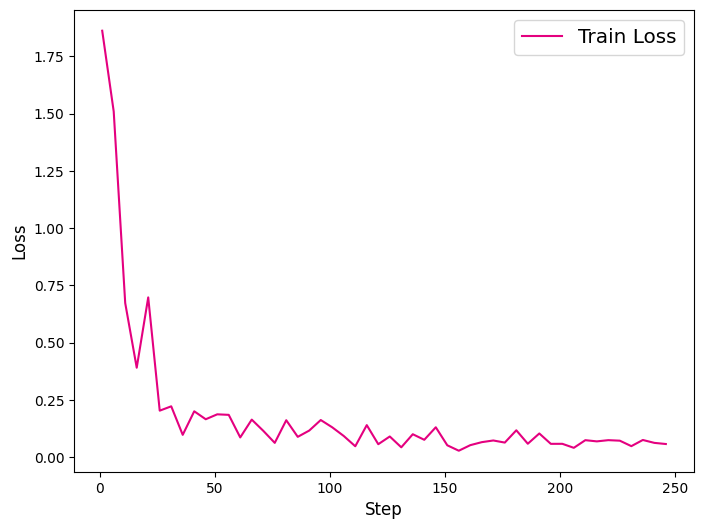

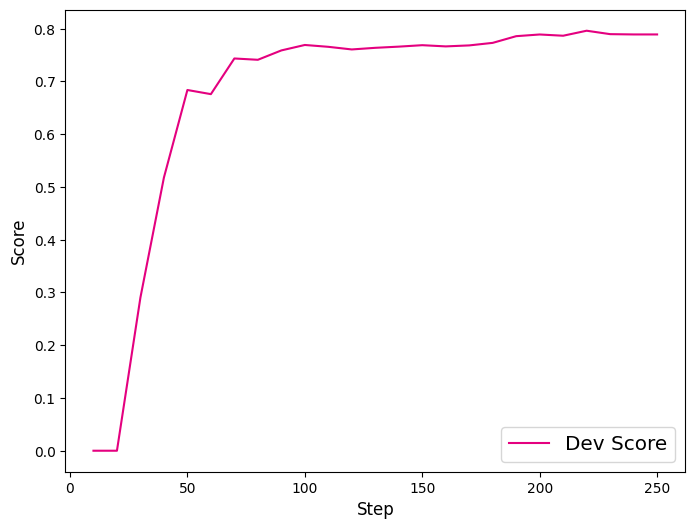

In [8]:
import matplotlib.pyplot as plt

def plot_training_loss(train_loss_record, fig_name, fig_size=(8, 6), sample_step=10, loss_legend_loc="lower left"):
    """
    绘制损失变化图

    输入:
        - train_loss_record: 训练过程中的损失记录
        - fig_name: 图片保存路径
        - fig_size: 设置图像尺寸
        - sample_step: 每隔sample_step会采样一个损失点，用以绘制图像
        - loss_legend_loc: 图例说明的位置
    """
    plt.figure(figsize=fig_size)

    train_steps = [x[0] for x in train_loss_record][::sample_step]
    train_losses = [x[1] for x in train_loss_record][::sample_step]

    plt.plot(train_steps, train_losses, color='#e4007f', label="Train Loss")
    # 绘制坐标轴和图例
    plt.ylabel("Loss", fontsize='large')
    plt.xlabel("Step", fontsize='large')
    plt.legend(loc=loss_legend_loc, fontsize='x-large')

    plt.savefig(fig_name)
    plt.show()

def plot_training_acc(train_score_record, fig_name, fig_size=(8, 6), sample_step=10, acc_legend_loc="lower left"):
    """
    绘制评估分数变化图

    输入:
        - train_score_record: 训练过程中的评估分数记录
        - fig_name: 图片保存路径
        - fig_size: 设置图像尺寸
        - sample_step: 每隔sample_step会采样一个损失点，用以绘制图像
        - acc_legend_loc: 图例说明的位置
    """
    plt.figure(figsize=fig_size)

    train_steps=[x[0] for x in train_score_record]
    train_losses = [x[1] for x in train_score_record]

    plt.plot(train_steps, train_losses, color='#e4007f', label="Dev Score")
    # 绘制坐标轴和图例
    plt.ylabel("Score", fontsize='large')
    plt.xlabel("Step", fontsize='large')
    plt.legend(loc=acc_legend_loc, fontsize='x-large')

    plt.savefig(fig_name)
    plt.show()


fig_path = "./images/chapter7_loss.pdf"
plot_training_loss(train_loss_record, fig_path, loss_legend_loc="upper right", sample_step=5)

fig_path = "./images/chapter7_acc.pdf"
plot_training_acc(train_score_record, fig_path, sample_step=1, acc_legend_loc="lower right")

In [9]:
def predict(input_text, ext_model, tokenizer, ext_id2label, max_seq_len=512):
    encoded_inputs = tokenizer(list(input_text), is_split_into_words=True, max_seq_len=max_seq_len,)
    input_ids = paddle.to_tensor([encoded_inputs["input_ids"]])
    token_type_ids = paddle.to_tensor([encoded_inputs["token_type_ids"]])

    logits = ext_model(input_ids, token_type_ids=token_type_ids)
    predictions = logits.argmax(axis=2).numpy()
    print(predictions.shape)
    predictions = predictions[0]
    tag_seq = [ext_id2label[idx] for idx in predictions][1:-1]
    
    print("text: ", input_text)
    print("预测结果: ", tag_seq)
    return tag_seq

max_seq_len = 512

input_text = "蛋糕的味道不错，很棒，店家的服务也很热情"
predict(input_text, ext_model, tokenizer, ext_id2label,  max_seq_len=max_seq_len)

(1, 22)
text:  蛋糕的味道不错，很棒，店家的服务也很热情
预测结果:  ['O', 'O', 'O', 'B-Aspect', 'I-Aspect', 'B-Opinion', 'I-Opinion', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-Aspect', 'I-Aspect', 'O', 'O', 'B-Opinion', 'I-Opinion']


/home/ricaedo/下载/yes/envs/paddle/lib/python3.10/site-packages/paddlenlp/transformers/tokenizer_utils_base.py:2353: FutureWarning: The `max_seq_len` argument is deprecated and will be removed in a future version, please use `max_length` instead.
  warnings.warn(
/home/ricaedo/下载/yes/envs/paddle/lib/python3.10/site-packages/paddlenlp/transformers/tokenizer_utils_base.py:1925: UserWarning: Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
  warnings.warn(


['O',
 'O',
 'O',
 'B-Aspect',
 'I-Aspect',
 'B-Opinion',
 'I-Opinion',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'B-Aspect',
 'I-Aspect',
 'O',
 'O',
 'B-Opinion',
 'I-Opinion']

In [10]:
from seqeval.metrics.sequence_labeling import get_entities


def decoding(text, tag_seq):
    # 确保输入序列和标签序列长度一致
    assert len(text) == len(tag_seq), f"text len: {len(text)}, tag_seq len: {len(tag_seq)}"
    
    puncs = list(",.?;!，。？；！")
    splits = [idx for idx in range(len(text)) if text[idx] in puncs]
    prev = 0
    sub_texts, sub_tag_seqs = [], []
    for split in splits:
        sub_tag_seqs.append(tag_seq[prev:split])
        sub_texts.append(text[prev:split])
        prev = split
    sub_tag_seqs.append(tag_seq[prev:])
    sub_texts.append((text[prev:]))
    ents_list = []
    for sub_text, sub_tag_seq in zip(sub_texts, sub_tag_seqs):
        ents = get_entities(sub_tag_seq, suffix=False)
        ents_list.append((sub_text, ents))
    aps = []
    no_a_words = []
    for sub_text_seq, ent_list in ents_list:
        sub_aps = []
        sub_no_a_words = []
        for ent in ent_list:
            ent_name, start, end = ent
            if ent_name == "Aspect":
                aspect = sub_text_seq[start:end+1]
                sub_aps.append([aspect])
                if len(sub_no_a_words) > 0:
                    sub_aps[-1].extend(sub_no_a_words)
                    sub_no_a_words.clear()
            else:
                ent_name == "Opinion"
                opinion = sub_text_seq[start:end + 1]
                if len(sub_aps) > 0:
                    sub_aps[-1].append(opinion)
                else:
                    sub_no_a_words.append(opinion)

        # 如果当前sub_aps非空，则将其添加至aps
        if sub_aps:
            aps.extend(sub_aps)
            if len(no_a_words) > 0:
                aps[-1].extend(no_a_words)
                no_a_words.clear()
        elif sub_no_a_words:
            if len(aps) > 0:
                aps[-1].extend(sub_no_a_words)
            else:
                no_a_words.extend(sub_no_a_words)

    if no_a_words:
        no_a_words.insert(0, "None")
        aps.append(no_a_words)

    return aps 

In [11]:
text = "蛋糕的味道不错，很棒，店家的服务也很热情"
tag_seq = ['O', 'O', 'O', 'B-Aspect', 'I-Aspect', 'B-Opinion', 'I-Opinion', 'O', 'O', 'B-Opinion', 'O', 'O', 'O', 'O', 'B-Aspect', 'I-Aspect', 'O', 'O', 'B-Opinion', 'I-Opinion']

aps = decoding(text, tag_seq)

for ap in aps:
    aspect, opinion = ap[0], set(ap[1:])
    print(f"aspect: {aspect}, opinion: {opinion}\n")

aspect: 味道, opinion: {'不错', '棒'}

aspect: 服务, opinion: {'热情'}



In [12]:
from datasets import load_dataset
train_path = "./data/data178685/train_cls.json"
dev_path = "./data/data178685/dev_cls.json"
test_path = "./data/data178685/test_cls.json"
dataset = load_dataset("json", data_files={"train":train_path, "dev":dev_path, "test":test_path})

# 打印训练集的前3条数据
print(dataset["train"][:3])

{'text': ['服务和环境都不错……', '服务态度挺好的，还给吹了一个不错的造型', '服务态度挺好的，还给吹了一个不错的造型'], 'aspect_text': ['环境不错', '不错造型', '服务态度挺好'], 'label': ['正向', '正向', '正向']}


In [13]:
def convert_example_to_feature(example,tokenizer,label2id, max_seq_len=512, is_infer=False):
    encoded_inputs = tokenizer(text=example["aspect_text"], text_pair=example["text"],  max_seq_len=max_seq_len, return_length=True)
    if not is_infer:
        encoded_inputs["label"] = label2id[example["label"]]
    
    return encoded_inputs

max_seq_len = 128
# 定义模型名称
model_name = "bert-base-chinese"
# 定义Bert Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)
# 定义词典
cls_label2id = {"负向":0, "正向":1}
cls_id2label = {v: k for k, v in cls_label2id.items()}

# 将数据转换成特征形式
trans_fn = partial(convert_example_to_feature, tokenizer=tokenizer, label2id=cls_label2id, max_seq_len=max_seq_len)
columns = ["text", "aspect_text", "label"]
train_dataset = dataset["train"].map(trans_fn, batched=False, remove_columns=columns)
dev_dataset = dataset["dev"].map(trans_fn, batched=False, remove_columns=columns)
test_dataset = dataset["test"].map(trans_fn, batched=False, remove_columns=columns)

# 输出每个数据集中的样本数量
print("train_dataset:", len(train_dataset))
print("dev_dataset:", len(dev_dataset))
print("test_dataset:", len(test_dataset))
# 输出训练集示例
print("train example:", train_dataset[:1])

[2026-03-09 22:31:37,637] [    INFO] - We are using (<class 'paddlenlp.transformers.bert.tokenizer.BertTokenizer'>, False) to load 'bert-base-chinese'.
[2026-03-09 22:31:37,638] [    INFO] - Already cached /home/ricaedo/.paddlenlp/models/bert-base-chinese/bert-base-chinese-vocab.txt
[2026-03-09 22:31:37,645] [    INFO] - tokenizer config file saved in /home/ricaedo/.paddlenlp/models/bert-base-chinese/tokenizer_config.json
[2026-03-09 22:31:37,646] [    INFO] - Special tokens file saved in /home/ricaedo/.paddlenlp/models/bert-base-chinese/special_tokens_map.json
Map:   0%|          | 0/800 [00:00<?, ? examples/s]/home/ricaedo/下载/yes/envs/paddle/lib/python3.10/site-packages/paddlenlp/transformers/tokenizer_utils_base.py:3049: UserWarning: Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
  warnings.warn(
Map: 100%|

train_dataset: 800
dev_dataset: 100
test_dataset: 100
train example: {'label': [1], 'input_ids': [[101, 4384, 1862, 679, 7231, 102, 3302, 1218, 1469, 4384, 1862, 6963, 679, 7231, 100, 100, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], 'length': [17], 'seq_len': [17]}


In [14]:
from paddle.io import BatchSampler, DataLoader
from paddlenlp.data import DataCollatorWithPadding


batch_size= 4
train_sampler = BatchSampler(train_dataset, batch_size=batch_size, shuffle=True)
dev_sampler = BatchSampler(dev_dataset, batch_size=batch_size, shuffle=False)

# 使用预置的DataCollator
data_collator = DataCollatorWithPadding(tokenizer)
train_loader = DataLoader(dataset=train_dataset, batch_sampler=train_sampler, collate_fn=data_collator)
dev_loader = DataLoader(dataset=dev_dataset, batch_sampler=dev_sampler, collate_fn=data_collator)
test_loader = DataLoader(dataset=test_dataset, batch_sampler=dev_sampler, collate_fn=data_collator)


In [15]:
from paddlenlp.transformers import AutoModelForSequenceClassification

# 本案例中有正面、负面两类数据，因此需要设置类别数量为2
num_classes = 2
cls_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_classes=num_classes)

[2026-03-09 22:31:38,019] [    INFO] - We are using <class 'paddlenlp.transformers.bert.modeling.BertForSequenceClassification'> to load 'bert-base-chinese'.
[2026-03-09 22:31:38,020] [    INFO] - Already cached /home/ricaedo/.paddlenlp/models/bert-base-chinese/model_state.pdparams
[2026-03-09 22:31:38,020] [    INFO] - Loading weights file model_state.pdparams from cache at /home/ricaedo/.paddlenlp/models/bert-base-chinese/model_state.pdparams
[2026-03-09 22:31:38,221] [    INFO] - Loaded weights file from disk, setting weights to model.
[2026-03-09 22:31:38,279] [ WARNING] - Some weights of the model checkpoint at bert-base-chinese were not used when initializing BertForSequenceClassification: ['cls.predictions.decoder_bias', 'cls.predictions.decoder_weight', 'cls.predictions.layer_norm.bias', 'cls.predictions.layer_norm.weight', 'cls.predictions.transform.bias', 'cls.predictions.transform.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you 

In [16]:
import os
import paddle
import paddle.nn as nn
from paddlenlp.transformers import LinearDecayWithWarmup



num_epochs = 5

learning_rate = 3e-5

eval_steps = 10

log_steps = 10

save_dir = "./checkpoints"


weight_decay = 0.01

warmup_proportion = 0.1
num_training_steps = len(train_loader) * num_epochs

if not os.path.exists(save_dir):
    os.mkdir(save_dir)

decay_params = [
        p.name for n, p in cls_model.named_parameters()
        if not any(nd in n for nd in ["bias", "norm"])
    ]

# 定义lr_scheduler, 在warmup阶段学习率线性增加，warmup阶段之后，学习率会逐步衰减
lr_scheduler = LinearDecayWithWarmup(learning_rate=learning_rate,
                                     total_steps=num_training_steps,
                                     warmup=warmup_proportion)

# 初始化优化器
optimizer = paddle.optimizer.AdamW(
        learning_rate=lr_scheduler,
        parameters=cls_model.parameters(),
        weight_decay=weight_decay,
        apply_decay_param_fun=lambda x: x in decay_params)

# 定义损失函数
loss_fn = nn.CrossEntropyLoss()

# 定义评估指标计算方式
metric = paddle.metric.Accuracy()

In [17]:
def evaluate(model, data_loader, metric):

    model.eval()
    metric.reset()
    with paddle.no_grad():
        for batch_data in data_loader:
            input_ids, token_type_ids, labels = batch_data["input_ids"],  batch_data["token_type_ids"], batch_data["labels"]
            logits = model(input_ids, token_type_ids=token_type_ids)      
            correct = metric.compute(logits, labels)
            metric.update(correct)

        accuracy = metric.accumulate()
    return accuracy

In [18]:

def train(model):
    # 开启模型训练模式
    model.train()
    global_step, best_acc = 1, 0.
    # 记录训练过程中的loss 和 在验证集上模型评估的分数
    train_loss_record = []
    train_score_record = []
    for epoch in range(1, num_epochs+1):
        for batch_data in train_loader:
            input_ids, token_type_ids, labels = batch_data["input_ids"],  batch_data["token_type_ids"], batch_data["labels"]
            logits = model(input_ids, token_type_ids=token_type_ids)            
            loss = F.cross_entropy(logits, labels)
            train_loss_record.append((global_step, loss.item()))

            loss.backward()
            lr_scheduler.step()
            optimizer.step()
            optimizer.clear_grad()

            if global_step > 0 and global_step % log_steps == 0:
                print(f"epoch: {epoch} - global_step: {global_step}/{num_training_steps} - loss:{loss.numpy().item():.6f}")
            if (global_step > 0 and global_step % eval_steps == 0) or global_step == num_training_steps:
                accuracy  = evaluate(model, dev_loader,  metric)
                train_score_record.append((global_step, accuracy))
                model.train()
                if accuracy > best_acc:
                    print(f"best accuracy performence has been updated: {best_acc:.5f} --> {accuracy:.5f}")
                    best_acc = accuracy
                    paddle.save(model.state_dict(), f"{save_dir}/best_cls.pdparams")
                print(f'evalution result: accuracy:{accuracy:.5f}')

            global_step += 1

    paddle.save(model.state_dict(), f"{save_dir}/final_cls.pdparams")

    return train_loss_record, train_score_record

train_loss_record, train_score_record = train(cls_model)

epoch: 1 - global_step: 10/1000 - loss:0.667746
best accuracy performence has been updated: 0.00000 --> 0.79000
evalution result: accuracy:0.79000
epoch: 1 - global_step: 20/1000 - loss:0.544976
evalution result: accuracy:0.79000
epoch: 1 - global_step: 30/1000 - loss:0.490309
evalution result: accuracy:0.79000
epoch: 1 - global_step: 40/1000 - loss:0.543381
evalution result: accuracy:0.79000
epoch: 1 - global_step: 50/1000 - loss:0.775752
evalution result: accuracy:0.79000
epoch: 1 - global_step: 60/1000 - loss:0.603094
evalution result: accuracy:0.79000
epoch: 1 - global_step: 70/1000 - loss:0.317664
evalution result: accuracy:0.79000
epoch: 1 - global_step: 80/1000 - loss:0.472136
best accuracy performence has been updated: 0.79000 --> 0.91000
evalution result: accuracy:0.91000
epoch: 1 - global_step: 90/1000 - loss:0.166866
evalution result: accuracy:0.74000
epoch: 1 - global_step: 100/1000 - loss:0.038167
evalution result: accuracy:0.87000
epoch: 1 - global_step: 110/1000 - loss:0

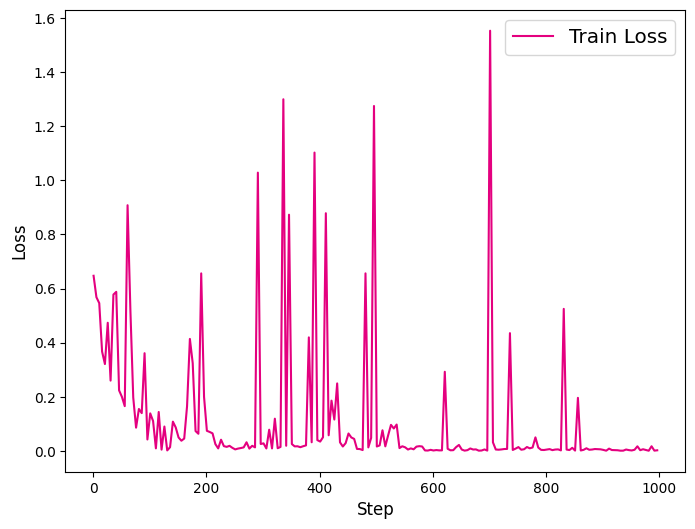

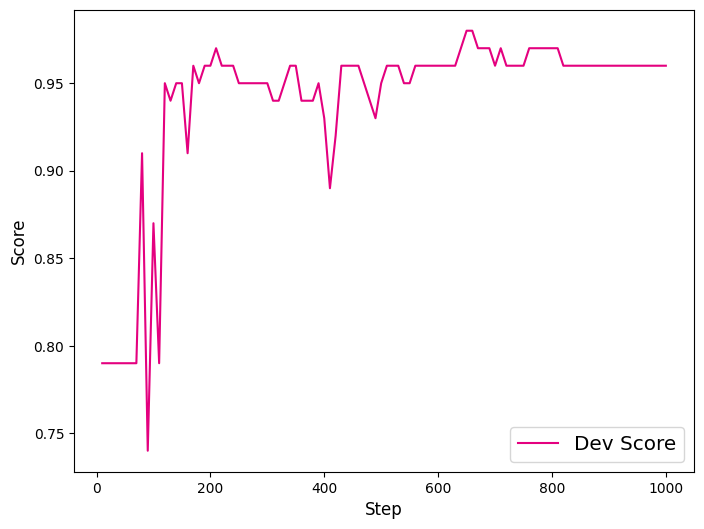

In [19]:

fig_path = "./images/chapter7_loss2.pdf"
plot_training_loss(train_loss_record, fig_path, loss_legend_loc="upper right", sample_step=5)

fig_path = "./images/chapter7_acc2.pdf"
plot_training_acc(train_score_record, fig_path, sample_step=1, acc_legend_loc="lower right")

In [20]:
model_path = "./checkpoints/best_cls.pdparams"

loaded_state_dict = paddle.load(model_path)
cls_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_classes=2)  
cls_model.load_dict(loaded_state_dict)

[2026-03-09 22:32:39,371] [    INFO] - We are using <class 'paddlenlp.transformers.bert.modeling.BertForSequenceClassification'> to load 'bert-base-chinese'.
[2026-03-09 22:32:39,372] [    INFO] - Already cached /home/ricaedo/.paddlenlp/models/bert-base-chinese/model_state.pdparams
[2026-03-09 22:32:39,373] [    INFO] - Loading weights file model_state.pdparams from cache at /home/ricaedo/.paddlenlp/models/bert-base-chinese/model_state.pdparams
[2026-03-09 22:32:39,597] [    INFO] - Loaded weights file from disk, setting weights to model.
[2026-03-09 22:32:39,661] [ WARNING] - Some weights of the model checkpoint at bert-base-chinese were not used when initializing BertForSequenceClassification: ['cls.predictions.decoder_bias', 'cls.predictions.decoder_weight', 'cls.predictions.layer_norm.bias', 'cls.predictions.layer_norm.weight', 'cls.predictions.transform.bias', 'cls.predictions.transform.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you 

([], [])

In [21]:
def predict(input_text, aspect_text, cls_model, tokenizer, cls_id2label, max_seq_len=512):

    # 处理输入文本
    encoded_inputs = tokenizer(text=input_text, text_pair=aspect_text, max_seq_len=max_seq_len)
    input_ids = paddle.to_tensor([encoded_inputs["input_ids"]])
    token_type_ids = paddle.to_tensor([encoded_inputs["token_type_ids"]])

    # 计算情感极性
    logits = cls_model(input_ids, token_type_ids=token_type_ids)
    label_id = logits.argmax(axis=-1).numpy()[0]
    sentiment = cls_id2label[label_id]

    print("text: ", input_text)
    print("aspect_text: ", aspect_text)
    print("预测结果: ", sentiment)

max_seq_len = 512
input_text = "蛋糕的味道不错，就是外观有点差"
aspect_text = "外观差"

predict(input_text, aspect_text, cls_model, tokenizer, cls_id2label,  max_seq_len=max_seq_len)


text:  蛋糕的味道不错，就是外观有点差
aspect_text:  外观差
预测结果:  负向


/home/ricaedo/下载/yes/envs/paddle/lib/python3.10/site-packages/paddlenlp/transformers/tokenizer_utils_base.py:2353: FutureWarning: The `max_seq_len` argument is deprecated and will be removed in a future version, please use `max_length` instead.
  warnings.warn(


In [22]:
ext_label2id = {"O":0, "B-Aspect":1, "I-Aspect":2, "B-Opinion":3, "I-Opinion":4}
ext_id2label = {v: k for k, v in ext_label2id.items()}
cls_label2id = {"负向":0, "正向":1}
cls_id2label = {v: k for k, v in cls_label2id.items()}

# 加载tokenizer
model_name = "bert-base-chinese"
tokenizer = AutoTokenizer.from_pretrained(model_name)
print("tokenizer loaded.")

# 加载属性和观点抽取模型
ext_model_path = "./checkpoints/best_ext.pdparams"
ext_state_dict = paddle.load(ext_model_path)
ext_model = AutoModelForTokenClassification.from_pretrained(model_name, num_classes=5)  
ext_model.load_dict(ext_state_dict)
print("extraction model loaded.")

# 加载属性级情感分类模型
cls_model_path = "./checkpoints/best_cls.pdparams"
cls_state_dict = paddle.load(cls_model_path)
cls_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_classes=2)  
cls_model.load_dict(cls_state_dict)
print("classification model loaded.")

[2026-03-09 22:32:39,699] [    INFO] - We are using (<class 'paddlenlp.transformers.bert.tokenizer.BertTokenizer'>, False) to load 'bert-base-chinese'.
[2026-03-09 22:32:39,700] [    INFO] - Already cached /home/ricaedo/.paddlenlp/models/bert-base-chinese/bert-base-chinese-vocab.txt
[2026-03-09 22:32:39,705] [    INFO] - tokenizer config file saved in /home/ricaedo/.paddlenlp/models/bert-base-chinese/tokenizer_config.json
[2026-03-09 22:32:39,706] [    INFO] - Special tokens file saved in /home/ricaedo/.paddlenlp/models/bert-base-chinese/special_tokens_map.json
[2026-03-09 22:32:39,872] [    INFO] - We are using <class 'paddlenlp.transformers.bert.modeling.BertForTokenClassification'> to load 'bert-base-chinese'.
[2026-03-09 22:32:39,873] [    INFO] - Already cached /home/ricaedo/.paddlenlp/models/bert-base-chinese/model_state.pdparams
[2026-03-09 22:32:39,873] [    INFO] - Loading weights file model_state.pdparams from cache at /home/ricaedo/.paddlenlp/models/bert-base-chinese/model_s

tokenizer loaded.


[2026-03-09 22:32:40,077] [    INFO] - Loaded weights file from disk, setting weights to model.
[2026-03-09 22:32:40,139] [ WARNING] - Some weights of the model checkpoint at bert-base-chinese were not used when initializing BertForTokenClassification: ['cls.predictions.decoder_bias', 'cls.predictions.decoder_weight', 'cls.predictions.layer_norm.bias', 'cls.predictions.layer_norm.weight', 'cls.predictions.transform.bias', 'cls.predictions.transform.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification

extraction model loaded.


[2026-03-09 22:32:40,388] [    INFO] - Loaded weights file from disk, setting weights to model.
[2026-03-09 22:32:40,454] [ WARNING] - Some weights of the model checkpoint at bert-base-chinese were not used when initializing BertForSequenceClassification: ['cls.predictions.decoder_bias', 'cls.predictions.decoder_weight', 'cls.predictions.layer_norm.bias', 'cls.predictions.layer_norm.weight', 'cls.predictions.transform.bias', 'cls.predictions.transform.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClass

classification model loaded.


In [40]:
def predict(input_text, ext_model, cls_model, tokenizer, ext_id2label, cls_id2label, max_seq_len=512):

    ext_model.eval()
    cls_model.eval()

    # 处理输入文本数据
    encoded_inputs = tokenizer(list(input_text), is_split_into_words=True, max_seq_len=max_seq_len,)
    input_ids = paddle.to_tensor([encoded_inputs["input_ids"]])
    token_type_ids = paddle.to_tensor([encoded_inputs["token_type_ids"]])

    # 抽取属性和观点词
    logits = ext_model(input_ids, token_type_ids=token_type_ids)
    predictions = logits.argmax(axis=2).numpy()[0]
    tag_seq = [ext_id2label[idx] for idx in predictions][1:-1]
    aps = decoding(input_text, tag_seq)

    # 针对属性进行情感分类
    results = []
    for ap in aps:
        aspect = ap[0]
        opinion_words = list(set(ap[1:]))
        # 拼接属性和观点词
        aspect_text = ""
        for opinion_word in opinion_words:
            if input_text.find(aspect) <= input_text.find(opinion_word):
                aspect_text += aspect+opinion_word+"，"
            else:
                aspect_text += opinion_word+aspect+"，"
        aspect_text = aspect_text[:-1]
        
        encoded_inputs = tokenizer(aspect_text,
                                   text_pair=input_text,
                                   max_seq_len=max_seq_len,
                                   return_length=True)
        input_ids = paddle.to_tensor([encoded_inputs["input_ids"]])
        token_type_ids = paddle.to_tensor([encoded_inputs["token_type_ids"]])

        logits = cls_model(input_ids, token_type_ids=token_type_ids)
        prediction = logits.argmax(axis=1).numpy()[0]

        result = {"aspect": aspect, "opinions": opinion_words, "sentiment": cls_id2label[prediction]}
        results.append(result)

    # 打印预测结果
    for result in results:
        aspect, opinions, sentiment = result["aspect"], result["opinions"], result["sentiment"]
        print(f"aspect: {aspect}, opinions: {opinions}, sentiment: {sentiment}")

max_seq_len = 128
input_text = "这城市那么空，这回忆那么凶"
predict(input_text, ext_model, cls_model, tokenizer, ext_id2label, cls_id2label,  max_seq_len=max_seq_len)

aspect: 城市, opinions: [], sentiment: 负向
aspect: 回忆, opinions: [], sentiment: 负向
